<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 137 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Difference-in-Differences: Take It Further</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">Five extensions of the Chapter 137 analysis, each sharpening the causal claim: an event study, two-way fixed effects, a placebo-reassignment test, a standard-error comparison, and a demonstration of how a broken parallel-trends assumption biases the estimate.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
EM="#059669"; DEEP="#047857"; LIGHT="#a7f3d0"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREY="#94a3b8"; BLUE="#2563eb"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-difference-in-differences--loyalty_program.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-difference-in-differences--loyalty_program.xlsx", sheet_name="Data")
rng = np.random.default_rng(137)
base = smf.ols("revenue_per_customer ~ treated + post + treated:post", df).fit()
print(f"Chapter 137 DiD estimate = {base.params['treated:post']:.2f}")

Chapter 137 DiD estimate = 4.55


<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An event study</div>
<div style="color:#4a5578;margin-top:6px">Trace the effect month by month, and see parallel trends directly.</div>
</div>

Collapsing everything into one before-and-after hides the dynamics. An **event study** estimates the treated-versus-control gap in *each* month relative to launch. Two things should appear: the pre-launch points hover around **zero** (a direct picture of parallel trends), and the post-launch points jump to the effect size and stay there.

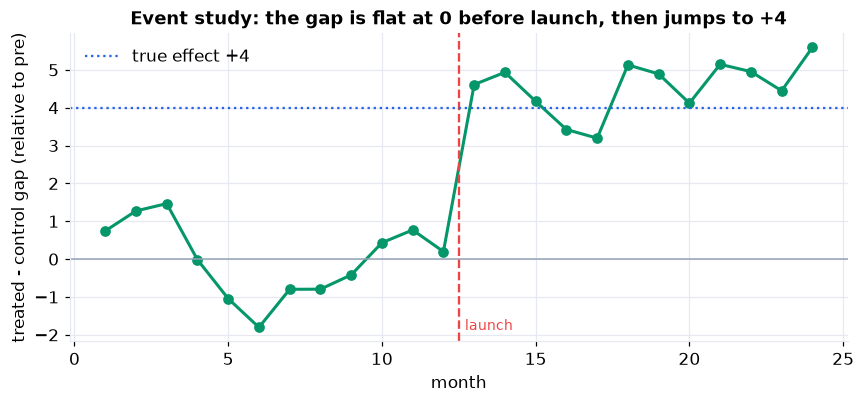

average gap BEFORE launch = +0.00  (should be ~0)
average gap AFTER launch  = +4.55  (the program effect)


In [2]:
# gap between the two group means each month, centered on the average PRE-launch gap
gap = df.groupby(['month','treated']).revenue_per_customer.mean().unstack()
gap = gap[1] - gap[0]                       # treated mean minus control mean, per month
gap = gap - gap[gap.index < 13].mean()      # subtract the baseline gap -> effect relative to pre-period
fig, ax = plt.subplots(figsize=(8,3.8))
ax.plot(gap.index, gap.values, marker='o', color=EM, lw=2)
ax.axhline(0, color=GREY, lw=1); ax.axvline(12.5, color=RED, ls='--', lw=1.5)
ax.axhline(4.0, color=BLUE, ls=':', lw=1.5, label='true effect +4')
ax.text(12.7, ax.get_ylim()[0]+0.3, 'launch', color=RED, fontsize=9)
ax.set(title='Event study: the gap is flat at 0 before launch, then jumps to +4', xlabel='month', ylabel='treated - control gap (relative to pre)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"average gap BEFORE launch = {gap[gap.index<13].mean():+.2f}  (should be ~0)")
print(f"average gap AFTER launch  = {gap[gap.index>=13].mean():+.2f}  (the program effect)")

The picture is the whole DiD argument at a glance: **flat and near zero before launch** (parallel trends, visually confirmed), then a clean step up to about **+4 after**. If the pre-launch points had trended up or down, the design would be in trouble. An event study is the single most persuasive DiD diagnostic.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two-way fixed effects</div>
<div style="color:#4a5578;margin-top:6px">The modern way to write the same estimator.</div>
</div>

The 2x2 regression used a `treated` dummy and a `post` dummy. The general form absorbs a full set of **store** and **month** fixed effects, letting every store have its own level and every month its own shock, and identifies the effect purely from the `treated:post` interaction. With just two groups and two periods it gives the same answer, but it is the estimator that scales to many units, many periods, and staggered rollouts.

In [3]:
twfe = smf.ols("revenue_per_customer ~ treated:post + C(store) + C(month)", df).fit(
        cov_type='cluster', cov_kwds={'groups': df['store']})
est = twfe.params['treated:post']; lo, hi = twfe.conf_int().loc['treated:post']
print(f"two-way fixed-effects DiD = {est:.2f}   95% clustered CI [{lo:.2f}, {hi:.2f}]")
print(f"simple 2x2 DiD            = {base.params['treated:post']:.2f}  (identical here; TWFE generalizes it)")

two-way fixed-effects DiD = 4.55   95% clustered CI [3.29, 5.81]
simple 2x2 DiD            = 4.55  (identical here; TWFE generalizes it)


Store and month fixed effects reproduce the **+4.55** estimate exactly. The value of writing it this way is generality: real evaluations have dozens of units adopting at different times, and two-way fixed effects (with the modern caveats about staggered timing) is the framework that handles them.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A placebo-reassignment test</div>
<div style="color:#4a5578;margin-top:6px">If a fake treatment finds an effect, the design is leaking.</div>
</div>

The chapter ran a placebo in *time*. Here we run one in *space*: ignore the real treatment, randomly label half the stores as a fake treated group, and run the DiD. With no real program driving anything, the estimate should scatter around **zero**. Repeating it many times builds a null distribution, and the real effect should sit far out in its tail.

placebo DiDs: mean +0.03, std 0.97   (centered on zero, as it should be)
real effect = 4.55  ->  0.0% of placebos are this extreme


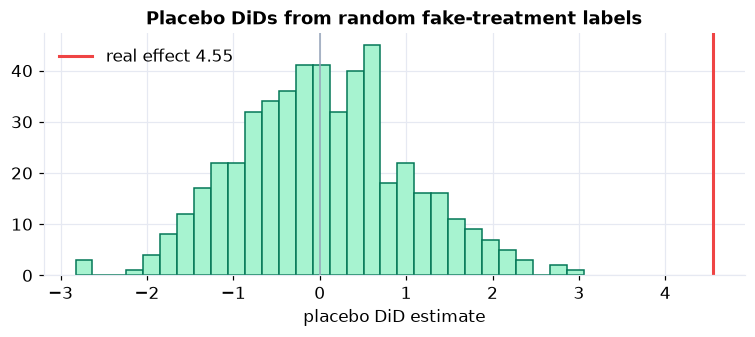

In [4]:
stores = df.store.unique()
def placebo_did():
    fake_t = set(rng.choice(stores, size=len(stores)//2, replace=False))
    d = df.copy(); d['ft'] = d.store.isin(fake_t).astype(int)
    return smf.ols('revenue_per_customer ~ ft + post + ft:post', d).fit().params['ft:post']
null = np.array([placebo_did() for _ in range(500)])
real = base.params['treated:post']
print(f"placebo DiDs: mean {null.mean():+.2f}, std {null.std():.2f}   (centered on zero, as it should be)")
print(f"real effect = {real:.2f}  ->  {(np.abs(null)>=real).mean()*100:.1f}% of placebos are this extreme")
fig, ax = plt.subplots(figsize=(7,3.2))
ax.hist(null, bins=30, color=LIGHT, edgecolor=DEEP)
ax.axvline(real, color=RED, lw=2, label=f'real effect {real:.2f}'); ax.axvline(0, color=GREY, lw=1)
ax.set(title='Placebo DiDs from random fake-treatment labels', xlabel='placebo DiD estimate'); ax.legend()
plt.tight_layout(); plt.show()

The placebo estimates cluster tightly around **zero**, and not one of the 500 random relabelings comes anywhere near the real **+4.55**. That is exactly the signature of a genuine effect: random group assignments produce nothing, so the real assignment is doing real work. A placebo distribution that overlapped the estimate would mean the effect could be an artifact of chance differences between stores.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Which standard error?</div>
<div style="color:#4a5578;margin-top:6px">Panel data punishes naive standard errors.</div>
</div>

The same point estimate can carry very different error bars depending on how you compute them. **Classical** standard errors assume every observation is independent, which is false when a store appears 24 times. **Robust (HC)** errors fix heteroscedasticity but still assume independence. **Clustered** errors, grouped by store, are the honest choice, and they are the widest.

In [5]:
specs = {
  'classical':  base,
  'robust HC1': smf.ols('revenue_per_customer ~ treated + post + treated:post', df).fit(cov_type='HC1'),
  'clustered':  smf.ols('revenue_per_customer ~ treated + post + treated:post', df).fit(cov_type='cluster', cov_kwds={'groups': df['store']}),
}
for name, m in specs.items():
    se = m.bse['treated:post']; lo, hi = m.conf_int().loc['treated:post']
    print(f"{name:11s} SE = {se:.3f}   95% CI [{lo:.2f}, {hi:.2f}]")
print("\n-> clustering gives the widest, most honest interval; report it for panel DiD.")

classical   SE = 0.491   95% CI [3.59, 5.51]
robust HC1  SE = 0.491   95% CI [3.59, 5.51]
clustered   SE = 0.622   95% CI [3.33, 5.77]

-> clustering gives the widest, most honest interval; report it for panel DiD.


The estimate never moves, but the **clustered interval is the widest** because it does not pretend a store's repeated months are independent evidence. Under-clustering is one of the most common ways applied DiD papers overstate their certainty. Cluster at the level treatment was assigned, here, the store.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When parallel trends breaks</div>
<div style="color:#4a5578;margin-top:6px">See the bias the assumption is protecting you from.</div>
</div>

Everything above rests on parallel trends. To feel why it matters, we **sabotage** it: add a gentle upward drift to the treated stores that has nothing to do with the program. Now the treated group was always going to pull ahead, and a DiD that assumes parallel trends will wrongly credit that drift to the program.

In [6]:
bad = df.copy()
# inject a fake differential trend: treated stores drift up 0.4/month for reasons unrelated to the program
bad.loc[bad.treated==1, 'revenue_per_customer'] += 0.4 * bad.loc[bad.treated==1, 'month']
pre = bad[bad.month<13]
pt = smf.ols('revenue_per_customer ~ treated*month', pre).fit()
biased = smf.ols('revenue_per_customer ~ treated + post + treated:post', bad).fit().params['treated:post']
print(f"differential PRE-trend now = {pt.params['treated:month']:+.2f}/month (p={pt.pvalues['treated:month']:.0e}) -> the test would CATCH this")
print(f"DiD on the sabotaged data  = {biased:.2f}   (true program effect is still 4.00 -> overstated by ~{biased-4:.1f})")

differential PRE-trend now = +0.34/month (p=9e-04) -> the test would CATCH this
DiD on the sabotaged data  = 9.35   (true program effect is still 4.00 -> overstated by ~5.3)


With a fake trend injected, the DiD balloons well above the true **+4.00**, crediting the program for a drift it did not cause. The reassuring part: the **pre-trend test now screams** (a large, highly significant differential slope), which is exactly why that check is not optional. Parallel trends is the assumption that turns a difference of differences into a causal claim, so test it, plot the event study, and be honest when it fails.

---
**The one idea to keep: difference-in-differences earns a causal claim only when the treated and control groups would have moved in parallel without the program, so the credibility of a DiD lives in its diagnostics, the event study, the placebo, the pre-trend test, at least as much as in the point estimate.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>